In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import robust_scale,minmax_scale
from sklearn.model_selection import KFold

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import L1L2, L1, L2
from tensorflow.keras.optimizers import Adam

/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
data = pd.read_csv("./../Data_Demo/filtered_input_train_no_lnc_features.csv", header=None)

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,677,678,679,680,681,682,683,684,685,686
0,82,2763,18.0,0.0,4.0,-1250.0,-17.950001,22.0,15.0,20.0,...,4.0,11.0,6.0,9.0,7.0,12.0,8.0,10.0,9.0,15.0
1,82,1127,3.0,1.0,3.0,570.0,-6.820000,22.0,15.0,20.0,...,0.0,8.0,4.0,6.0,9.0,4.0,5.0,9.0,9.0,30.0
2,82,1081,3.0,0.0,3.0,840.0,-6.820000,22.0,15.0,20.0,...,0.0,7.0,4.0,5.0,8.0,5.0,5.0,10.0,9.0,29.0
3,82,1202,3.0,0.0,2.0,140.0,-6.820000,22.0,15.0,20.0,...,0.0,8.0,5.0,5.0,8.0,6.0,6.0,11.0,9.0,32.0
4,82,1085,3.0,0.0,2.0,140.0,-6.820000,22.0,15.0,20.0,...,0.0,7.0,4.0,5.0,8.0,5.0,5.0,10.0,9.0,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,82,873,-1.0,-1.0,-1.0,0.0,0.000000,22.0,15.0,20.0,...,1.0,2.0,5.0,3.0,8.0,2.0,3.0,5.0,5.0,7.0
886,71,473,-1.0,-1.0,-1.0,0.0,0.000000,20.0,11.0,16.0,...,0.0,2.0,1.0,1.0,4.0,2.0,2.0,1.0,2.0,3.0
887,84,3201,13.0,0.0,3.0,-1390.0,-16.320000,24.0,13.0,23.0,...,2.0,22.0,15.0,10.0,17.0,31.0,31.0,26.0,32.0,102.0
888,82,8797,13.0,1.0,9.0,-950.0,-14.200000,22.0,15.0,20.0,...,1.0,64.0,57.0,37.0,45.0,49.0,93.0,84.0,79.0,174.0


In [4]:
labels = [1] * 528 + [0] * 362
labels = pd.DataFrame(labels)

In [5]:
train_data, test_data, train_label, test_label = train_test_split(data, labels, test_size=0.25, stratify=labels, random_state=42)
dim = len(train_data.columns)

In [6]:
k =  5
kf = KFold(n_splits=k,shuffle=True,random_state=42)
histories = []
scores = []

In [7]:
def get_model():
    model = Sequential()
    model.add(BatchNormalization(input_shape = (dim,)))
    model.add(Dense(150,activation = 'relu', bias_initializer='zeros', kernel_initializer = 'he_normal', kernel_regularizer=L2(0.002)))
    model.add(Dropout(0.4))
    model.add(Dense(75,activation = 'relu', bias_initializer='zeros', kernel_initializer = 'he_normal', kernel_regularizer=L2(0.002)))
    model.add(Dropout(0.4))
    model.add(Dense(20,activation = 'relu', bias_initializer='zeros', kernel_initializer = 'he_normal', kernel_regularizer=L2(0.002)))
    model.add(Dropout(0.4))
    model.add(Dense(1,activation = 'sigmoid', bias_initializer = 'zeros', kernel_initializer = 'glorot_normal'))
    return model

Epoch 1/200


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4841 - loss: 1.9220 - val_accuracy: 0.6418 - val_loss: 1.5821
Epoch 2/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step - accuracy: 0.5265 - loss: 1.7312 - val_accuracy: 0.6642 - val_loss: 1.5066
Epoch 3/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - accuracy: 0.5016 - loss: 1.6700 - val_accuracy: 0.7015 - val_loss: 1.4731
Epoch 4/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step - accuracy: 0.6292 - loss: 1.4883 - val_accuracy: 0.6642 - val_loss: 1.4408
Epoch 5/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step - accuracy: 0.6134 - loss: 1.5278 - val_accuracy: 0.6343 - val_loss: 1.4300
Epoch 6/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 701us/step - accuracy: 0.6255 - loss: 1.4810 - val_accuracy: 0.6866 - val_loss: 1.4038
Epoch 7/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step - accuracy: 0.6242 - loss: 1.4995 - val_accuracy: 0.6866 - val_loss: 1.3988
Epoch 8/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - accuracy: 0.6875 - loss: 1.4469 - val_ac

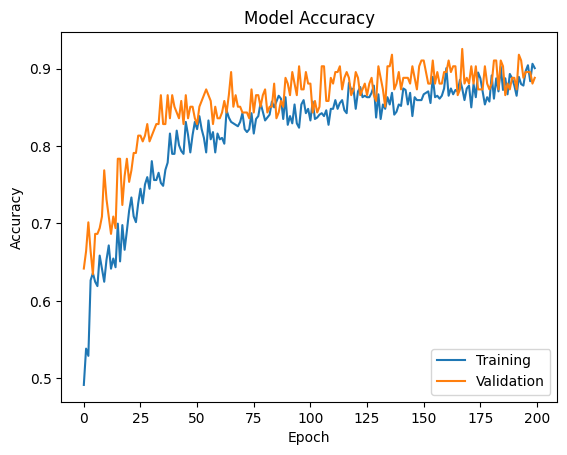

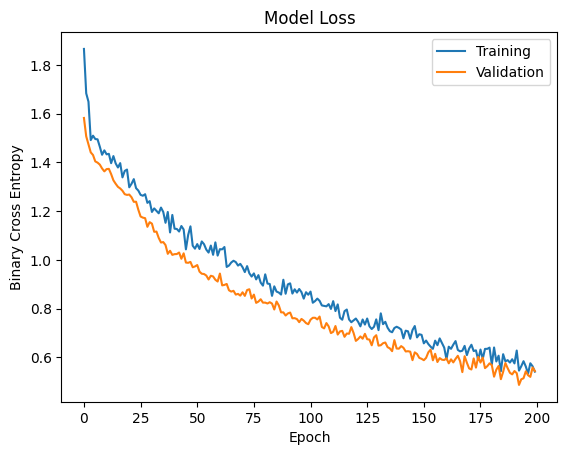

Epoch 1/200


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4931 - loss: 2.0223 - val_accuracy: 0.7239 - val_loss: 1.6795
Epoch 2/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step - accuracy: 0.5202 - loss: 1.8054 - val_accuracy: 0.6493 - val_loss: 1.6379
Epoch 3/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.5688 - loss: 1.6830 - val_accuracy: 0.6567 - val_loss: 1.5947
Epoch 4/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step - accuracy: 0.5844 - loss: 1.6848 - val_accuracy: 0.6567 - val_loss: 1.4950
Epoch 5/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step - accuracy: 0.6034 - loss: 1.5462 - val_accuracy: 0.6642 - val_loss: 1.4757
Epoch 6/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step - accuracy: 0.6396 - loss: 1.5073 - val_accuracy: 0.6642 - val_loss: 1.4672
Epoch 7/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step - accuracy: 0.6045 - loss: 1.5275 - val_accuracy: 0.6567 - val_loss: 1.4584
Epoch 8/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step - accuracy: 0.6182 - loss: 1.5648 - val_ac

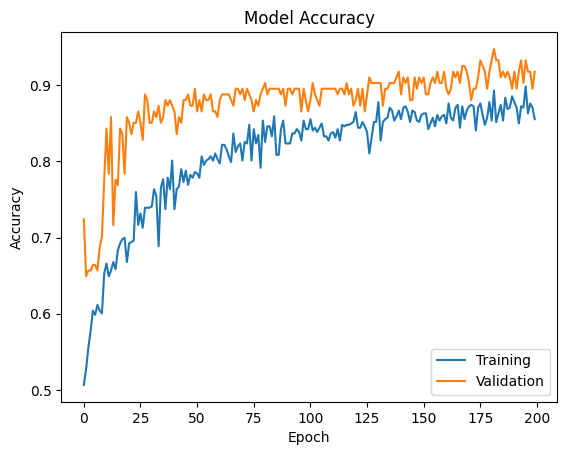

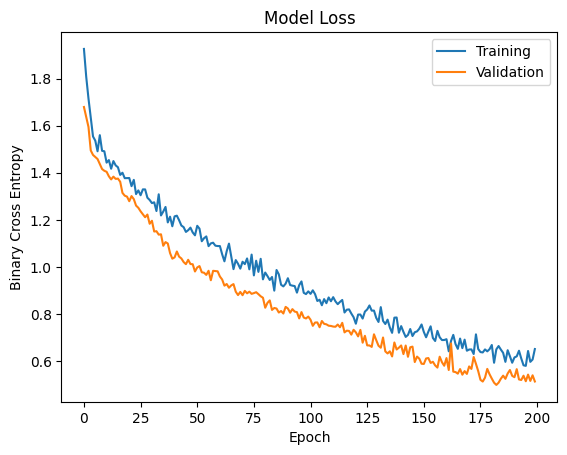

Epoch 1/200


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5354 - loss: 1.7396 - val_accuracy: 0.6466 - val_loss: 1.5950
Epoch 2/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - accuracy: 0.5625 - loss: 1.6804 - val_accuracy: 0.6917 - val_loss: 1.5026
Epoch 3/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step - accuracy: 0.6317 - loss: 1.5426 - val_accuracy: 0.7293 - val_loss: 1.4732
Epoch 4/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - accuracy: 0.6551 - loss: 1.5707 - val_accuracy: 0.7143 - val_loss: 1.4617
Epoch 5/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - accuracy: 0.6081 - loss: 1.5463 - val_accuracy: 0.6842 - val_loss: 1.4365
Epoch 6/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step - accuracy: 0.5970 - loss: 1.5121 - val_accuracy: 0.6917 - val_loss: 1.4297
Epoch 7/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.6343 - loss: 1.4758 - val_accuracy: 0.7293 - val_loss: 1.4175
Epoch 8/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step - accuracy: 0.6147 - loss: 1.4636 - val_ac

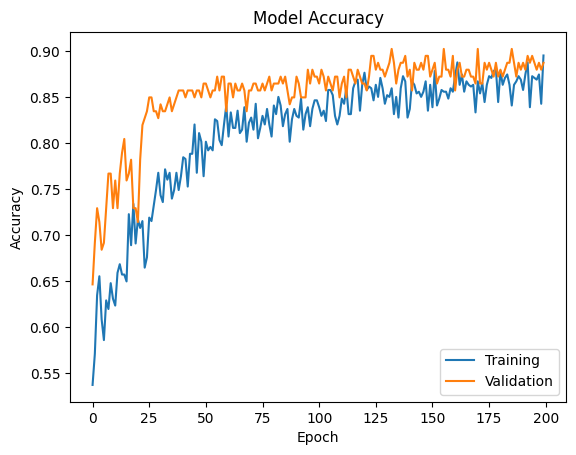

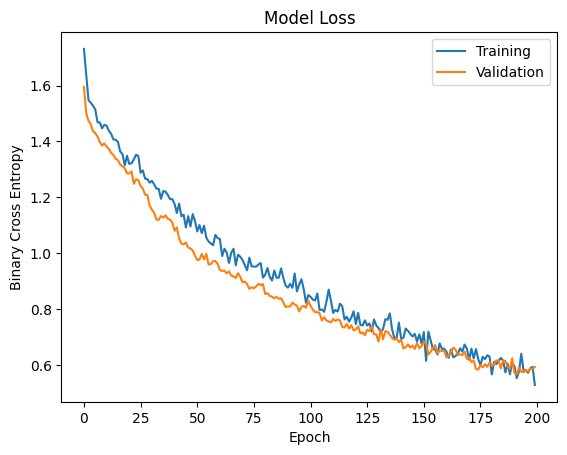

Epoch 1/200


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5163 - loss: 2.1180 - val_accuracy: 0.6391 - val_loss: 1.5869
Epoch 2/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step - accuracy: 0.5747 - loss: 1.7334 - val_accuracy: 0.6842 - val_loss: 1.4882
Epoch 3/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - accuracy: 0.5471 - loss: 1.7231 - val_accuracy: 0.7218 - val_loss: 1.4518
Epoch 4/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.5910 - loss: 1.6141 - val_accuracy: 0.7444 - val_loss: 1.4256
Epoch 5/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step - accuracy: 0.5755 - loss: 1.5866 - val_accuracy: 0.6992 - val_loss: 1.4025
Epoch 6/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step - accuracy: 0.6157 - loss: 1.5296 - val_accuracy: 0.6992 - val_loss: 1.3963
Epoch 7/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step - accuracy: 0.6154 - loss: 1.5200 - val_accuracy: 0.7744 - val_loss: 1.3729
Epoch 8/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.6841 - loss: 1.4768 - val_ac

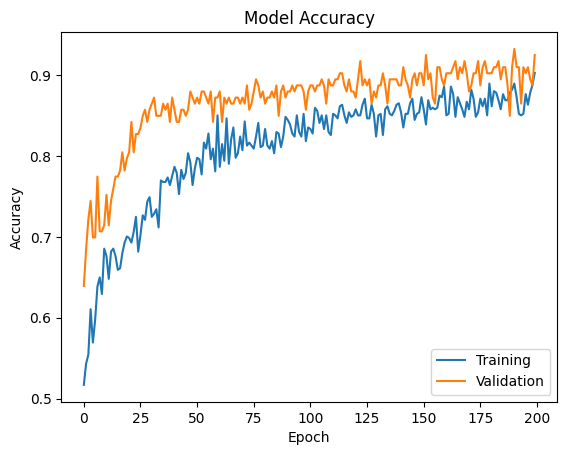

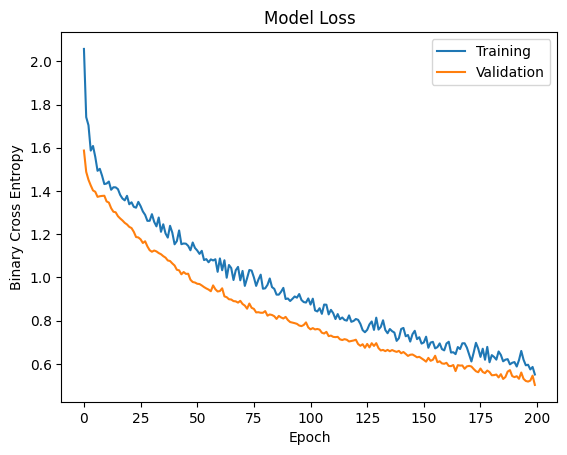

Epoch 1/200


/Users/andrescubillovillalobos/Library/Python/3.9/lib/python/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5218 - loss: 1.8427 - val_accuracy: 0.6767 - val_loss: 1.5558
Epoch 2/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - accuracy: 0.6014 - loss: 1.6440 - val_accuracy: 0.7218 - val_loss: 1.5013
Epoch 3/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - accuracy: 0.5687 - loss: 1.6604 - val_accuracy: 0.7519 - val_loss: 1.4635
Epoch 4/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step - accuracy: 0.6944 - loss: 1.4972 - val_accuracy: 0.7444 - val_loss: 1.4314
Epoch 5/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - accuracy: 0.5831 - loss: 1.5594 - val_accuracy: 0.7293 - val_loss: 1.4190
Epoch 6/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - accuracy: 0.6099 - loss: 1.5091 - val_accuracy: 0.7669 - val_loss: 1.4158
Epoch 7/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - accuracy: 0.6073 - loss: 1.4910 - val_accuracy: 0.7519 - val_loss: 1.3979
Epoch 8/200
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 718us/step - accuracy: 0.5684 - loss: 1.5464 - val_ac

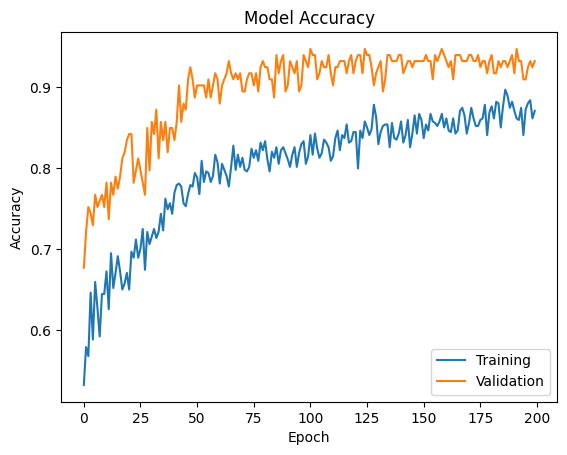

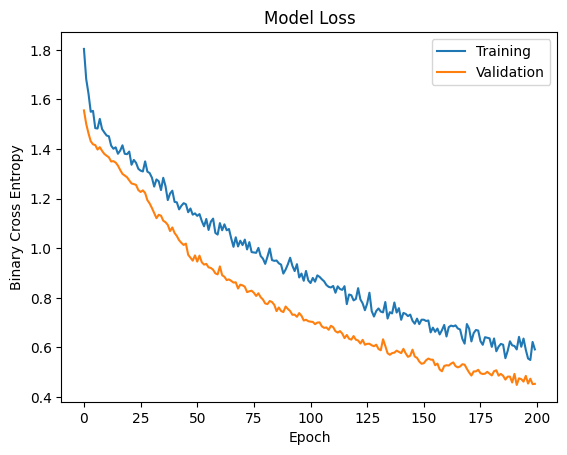

In [8]:
for train_index, test_index in kf.split(train_data):
    data_train, data_val = train_data.iloc[train_index], train_data.iloc[test_index]
    label_train, label_val = train_label.iloc[train_index], train_label.iloc[test_index]

    model = get_model()
    opt = Adam(0.0001)
    model.compile(optimizer=opt,loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(data_train,label_train,batch_size=4,epochs=200, validation_data = (data_val, label_val))
    
    score = model.evaluate(data_val, label_val)
    histories.append(history)
    scores.append(scores)

    # summarize history for accuracy
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='lower right')
    plt.show()

    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Binary Cross Entropy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='upper right')
    plt.show()